LAB 9

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

In [3]:
data = pd.read_csv("RockMine.csv", header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


Read the RockMine.csv from the dataset section.  There is no column header.

a. Add a column header by giving name to columns as C1, C2, .....

In [4]:
data.columns = [f"C{i}" for i in range(1, len(data.columns) + 1)]

In [5]:
data.head()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C52,C53,C54,C55,C56,C57,C58,C59,C60,C61
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


b. Sort its columns(except last label column) in increasing order of 'No.of distinct values'.

In [6]:
for col in data.columns:
    unique_vals = data[col].unique()
    print(f"{col} ({len(unique_vals)} unique)")

C1 (177 unique)
C2 (182 unique)
C3 (190 unique)
C4 (181 unique)
C5 (193 unique)
C6 (196 unique)
C7 (195 unique)
C8 (201 unique)
C9 (205 unique)
C10 (207 unique)
C11 (203 unique)
C12 (206 unique)
C13 (198 unique)
C14 (202 unique)
C15 (203 unique)
C16 (203 unique)
C17 (202 unique)
C18 (204 unique)
C19 (206 unique)
C20 (203 unique)
C21 (200 unique)
C22 (203 unique)
C23 (199 unique)
C24 (201 unique)
C25 (198 unique)
C26 (194 unique)
C27 (190 unique)
C28 (194 unique)
C29 (197 unique)
C30 (202 unique)
C31 (207 unique)
C32 (205 unique)
C33 (205 unique)
C34 (206 unique)
C35 (205 unique)
C36 (205 unique)
C37 (206 unique)
C38 (206 unique)
C39 (204 unique)
C40 (206 unique)
C41 (204 unique)
C42 (208 unique)
C43 (205 unique)
C44 (196 unique)
C45 (205 unique)
C46 (199 unique)
C47 (202 unique)
C48 (204 unique)
C49 (193 unique)
C50 (154 unique)
C51 (160 unique)
C52 (144 unique)
C53 (134 unique)
C54 (134 unique)
C55 (129 unique)
C56 (122 unique)
C57 (121 unique)
C58 (124 unique)
C59 (119 unique)
C60 (1

In [7]:
last_col = data.iloc[:, -1]
other_cols = data.iloc[:, :-1] 

sorted_cols = other_cols.nunique().sort_values().index
sorted_data = other_cols[sorted_cols].join(last_col)

sorted_data.head()

,C60,C59,C57,C56,C58,C55,C53,C54,C52,C50,...,C19,C38,C37,C12,C34,C40,C10,C31,C42,C61
0,0.0032,0.0090,0.0180,0.0167,0.0084,0.0072,0.0065,0.0159,0.0027,0.0324,...,0.5078,0.6097,0.6692,0.1582,0.7547,0.2744,0.2111,0.1307,0.2834,R
1,0.0044,0.0052,0.0140,0.0191,0.0049,0.0094,0.0089,0.0048,0.0084,0.0061,...,0.8024,0.1057,0.3835,0.6552,0.2341,0.1970,0.2872,0.3788,0.0583,R
2,0.0078,0.0095,0.0316,0.0244,0.0164,0.0180,0.0166,0.0095,0.0232,0.0106,...,0.8929,0.6756,0.6116,0.7060,0.2709,0.4719,0.6194,0.8512,0.2587,R
3,0.0117,0.0040,0.0050,0.0073,0.0044,0.0085,0.0036,0.0150,0.0121,0.0294,...,0.4060,0.8814,0.5408,0.1992,0.3497,0.9167,0.1264,0.6260,0.5006,R
4,0.0094,0.0107,0.0072,0.0015,0.0048,0.0110,0.0054,0.0105,0.0031,0.0046,...,0.2032,0.3217,0.4604,0.3952,0.0981,0.2430,0.4459,0.5103,0.2444,R


c. Remove the last 10 columns from the database.

In [18]:
print(sorted_data.columns[-11:])

Index(['C35', 'C19', 'C38', 'C37', 'C12', 'C34', 'C40', 'C10', 'C31', 'C42',
       'C61'],
      dtype='str')


In [8]:
target = sorted_data.iloc[:, -1]

In [9]:
reduced_data = sorted_data.iloc[:, :-11]
reduced_data = reduced_data.join(target)
reduced_data.head()

,C60,C59,C57,C56,C58,C55,C53,C54,C52,C50,...,C41,C18,C39,C32,C9,C33,C36,C43,C45,C61
0,0.0032,0.0090,0.0180,0.0167,0.0084,0.0072,0.0065,0.0159,0.0027,0.0324,...,0.0510,0.2999,0.4943,0.2604,0.3109,0.5121,0.8507,0.2825,0.2641,R
1,0.0044,0.0052,0.0140,0.0191,0.0049,0.0094,0.0089,0.0048,0.0084,0.0061,...,0.1674,0.8874,0.1840,0.2947,0.3337,0.1984,0.4182,0.1401,0.0621,R
2,0.0078,0.0095,0.0316,0.0244,0.0164,0.0180,0.0166,0.0095,0.0232,0.0106,...,0.4647,0.7551,0.5375,0.5045,0.5598,0.1862,0.3043,0.2129,0.2111,R
3,0.0117,0.0040,0.0050,0.0073,0.0044,0.0085,0.0036,0.0150,0.0121,0.0294,...,0.6121,0.2281,0.9857,0.7340,0.0598,0.6120,0.3012,0.3210,0.4295,R
4,0.0094,0.0107,0.0072,0.0015,0.0048,0.0110,0.0054,0.0105,0.0031,0.0046,...,0.1979,0.6193,0.2828,0.5459,0.3564,0.2881,0.4181,0.1847,0.0692,R


d. Normalize other columns by subtracting each value from Mean value and dividing by Mean standard deviation.

In [10]:
for col in reduced_data.columns[:-1]:
    mean = np.mean(reduced_data[col])
    std = np.std(reduced_data[col])
    reduced_data[col] = (reduced_data[col] - mean) / std

reduced_data.head()

,C60,C59,C57,C56,C58,C55,C53,C54,C52,C50,...,C41,C18,C39,C32,C9,C33,C36,C43,C45,C61
0,-0.658947,0.171678,1.763784,1.481635,0.069870,-0.295646,-0.597604,0.680897,-1.115432,0.878510,...,-1.395741,-0.584202,0.848461,-0.839777,1.125272,0.460548,1.768039,0.259328,0.442062,R
1,-0.419852,-0.444554,1.070732,1.901046,-0.472406,0.015503,-0.256857,-0.843151,-0.522349,-1.050756,...,-0.713840,1.667619,-0.714012,-0.678535,1.318325,-1.062150,0.126582,-0.767653,-0.893356,R
2,0.257582,0.252761,4.120162,2.827246,1.309360,1.231812,0.836373,-0.197833,1.017585,-0.720654,...,1.027820,1.160528,1.065989,0.307721,3.232767,-1.121368,-0.305701,-0.242623,0.091680,R
3,1.034640,-0.639154,-0.488635,-0.161060,-0.549875,-0.111785,-1.009341,0.557326,-0.137365,0.658442,...,1.891327,-0.859403,3.322838,1.386586,-1.000852,0.945462,-0.317466,0.536988,1.535517,R
4,0.576375,0.447361,-0.107456,-1.174638,-0.487900,0.241793,-0.753780,-0.060532,-1.073812,-1.160790,...,-0.535163,0.640022,-0.216518,0.502340,1.510531,-0.626746,0.126202,-0.446000,-0.846418,R


e. Run Any classification algorithm on new normalized dataset and report the accuracy.

In [11]:
X = reduced_data.iloc[:, :-1]
y = reduced_data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
svm = SVC(kernel='rbf') 
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred)

print("SVM Accuracy:", acc_svm)

SVM Accuracy: 0.9047619047619048


In [13]:
from sklearn.metrics import classification_report
print("\nSVM Report:\n", classification_report(y_test, y_pred))


SVM Report:
               precision    recall  f1-score   support

           M       0.96      0.88      0.92        26
           R       0.83      0.94      0.88        16

    accuracy                           0.90        42
   macro avg       0.90      0.91      0.90        42
weighted avg       0.91      0.90      0.91        42



f. Scale all the features and normalize it. Discretize it to 5 levels

Gradually remove the features till you get the accuracy in the range.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_binned = np.floor(X_scaled * 5).astype(int)
X_binned[X_binned == 5] = 4

print(X_binned[:1])

[[0 1 2 2 0 0 0 2 0 1 1 0 0 0 3 0 0 1 3 4 2 1 2 3 1 3 0 1 2 1 2 1 1 0 0 0
  1 2 0 2 2 0 1 2 1 2 2 4 1 1]]


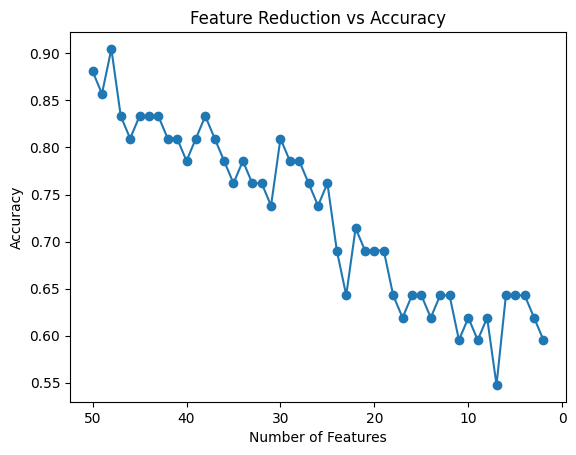

In [ ]:
feature_counts = []
accuracies = []
max_acc = 0
best_features_count = 0

n_features = X_binned.shape[1]

for k in range(n_features, 1, -1):  
    X_subset = X_binned[:, :k]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_subset, y, test_size=0.2, random_state=42
    )
    
    model = SVC(kernel='rbf')
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    if acc > max_acc:
        max_acc = acc
        best_features_count = k

    feature_counts.append(k)
    accuracies.append(acc)

plt.figure()
plt.plot(feature_counts, accuracies, marker='o')
plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.title("Feature Reduction vs Accuracy")
plt.gca().invert_xaxis() 
plt.show()

In [22]:
print(max_acc)
print(best_features_count)

0.9047619047619048
48
